In [11]:
import os
import re
import json
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
# -----------------------------------
# CONFIG
# -----------------------------------
MINISTRY_DIR = "../data/ministry_profiles"
STOPWORD_FILES = ["../data/stopwords/GBparl_stopwords-empirical.txt", "../data/stopwords/stopwords.txt"]
OUTPUT_FILE = "../data/vocabulary/ministry_tfidf_vocab.json"
TOP_N = 100
MAX_MINISTRY_REPEAT = 10

In [13]:
# -----------------------------------
# Load Custom Stopwords
# -----------------------------------

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def load_stopwords(custom_files) -> list[str]:

    stopwords = set(ENGLISH_STOP_WORDS)

    # load domain stopwords
    for custom_file in custom_files:
        with open(custom_file, "r", encoding="utf-8") as f:
            for line in f:
                word = line.strip().lower()
                if word:
                    stopwords.add(word)

    return list(stopwords)


In [14]:
# -----------------------------------
# 1. Text Cleaning Function
# -----------------------------------
def clean_text(text_data, stopwords=None):
    """
    - Lowercase
    - Remove numbers
    - Keep only alphabets
    - Remove extra spaces
    """

    text_data = text_data.lower()

    # Remove numbers
    text_data = re.sub(r'\d+', ' ', text_data)

    # Keep only alphabets
    text_data = re.sub(r'[^a-z\s]', ' ', text_data)

    # Remove extra spaces
    text_data = re.sub(r'\s+', ' ', text_data).strip()
    
    # Remove stopwords
    if stopwords:
        words = [w for w in text_data.split() if w not in stopwords]
        text_data = " ".join(words)


    return text_data


# -----------------------------------
# 2. Load Ministry Text Files
# -----------------------------------
def load_ministry_files(directory, stopwords=None):
    ministries = {}

    for file in os.listdir(directory):
        if file.endswith(".txt"):
            file_path = os.path.join(directory, file)

            with open(file_path, "r", encoding="utf-8") as f:
                text_data = f.read()

            cleaned = clean_text(text_data, stopwords)

            ministry_name = file.replace(".txt", "")
            ministries[ministry_name] = cleaned

    return ministries


# -----------------------------------
# 3. TF-IDF Keyword Extraction
# -----------------------------------
def extract_tfidf_keywords(ministries, top_n=100, max_ministry_occurrence=10):
    docs = list(ministries.values())
    names = list(ministries.keys())
    
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_df=0.85,
        min_df=3,
        ngram_range=(1, 2),  # unigrams + bigrams
        token_pattern=r'\b[a-z]{3,}\b'  # only alphabet words >=3 letters
    )

    tfidf_matrix = vectorizer.fit_transform(docs)
    feature_names = vectorizer.get_feature_names_out()

    # -----------------------------------
    # Count in how many ministries each word appears
    # -----------------------------------
    from collections import defaultdict
    word_ministry_count = defaultdict(int)

    for col_idx, word in enumerate(feature_names):
        column = tfidf_matrix[:, col_idx].toarray().flatten()
        count = (column > 0).sum()
        word_ministry_count[word] = count

    # -----------------------------------
    # Extract filtered top words per ministry
    # -----------------------------------
    ministry_keywords = {}

    for idx, name in enumerate(names):
        row = tfidf_matrix[idx].toarray().flatten()

        # Get sorted indices by tfidf score
        sorted_indices = row.argsort()[::-1]

        keywords = []
        for i in sorted_indices:
            word = feature_names[i]

            # Skip words appearing in too many ministries
            if word_ministry_count[word] > max_ministry_occurrence:
                continue

            if row[i] > 0:
                keywords.append(word)

            if len(keywords) >= top_n:
                break

        ministry_keywords[name] = keywords

    return ministry_keywords


# -----------------------------------
# 4. Save Vocabulary File
# -----------------------------------
def save_vocab(vocab_dict, output_file):
    Path(os.path.dirname(output_file)).mkdir(parents=True, exist_ok=True)

    with open(output_file, "w", encoding="utf-8") as f:
        json.dump(vocab_dict, f, indent=4)

    print(f"Vocabulary saved to: {output_file}")

In [15]:
print("Loading stopwords...")
custom_stopwords = load_stopwords(STOPWORD_FILES)

print("Loading ministry files...")
ministries = load_ministry_files(MINISTRY_DIR, custom_stopwords)
print(f"Total ministries loaded: {len(ministries)}")

print("Extracting TF-IDF keywords...")
ministry_keywords = extract_tfidf_keywords(ministries, top_n=TOP_N, max_ministry_occurrence=MAX_MINISTRY_REPEAT)

print("Saving vocabulary...")
save_vocab(ministry_keywords, OUTPUT_FILE)

Loading stopwords...
Loading ministry files...
Total ministries loaded: 53
Extracting TF-IDF keywords...
Saving vocabulary...
Vocabulary saved to: ../data/vocabulary/ministry_tfidf_vocab.json


In [16]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

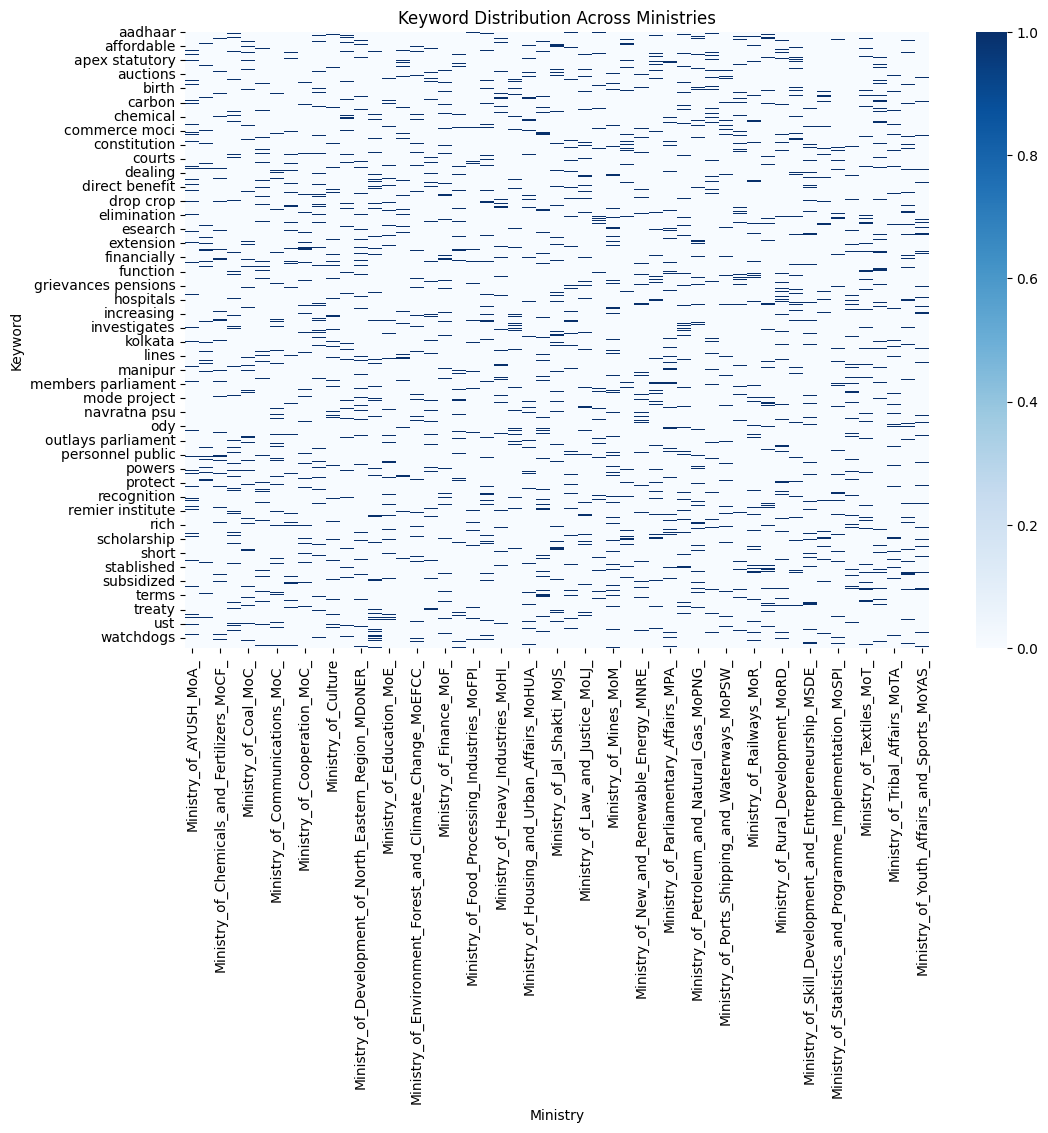

In [17]:
# build dataframe
data = []

for ministry, words in ministry_keywords.items():
    for w in words[:]:
        data.append((ministry, w, 1))

df = pd.DataFrame(data, columns=["Ministry","Keyword","Value"])

pivot = df.pivot(index="Keyword", columns="Ministry", values="Value").fillna(0)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="Blues")

plt.title("Keyword Distribution Across Ministries")
plt.show()

In [18]:
from collections import Counter

counter = Counter()

for ministry, words in ministry_keywords.items():
    counter.update(words)

# get top words
top_words = counter.most_common(100)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

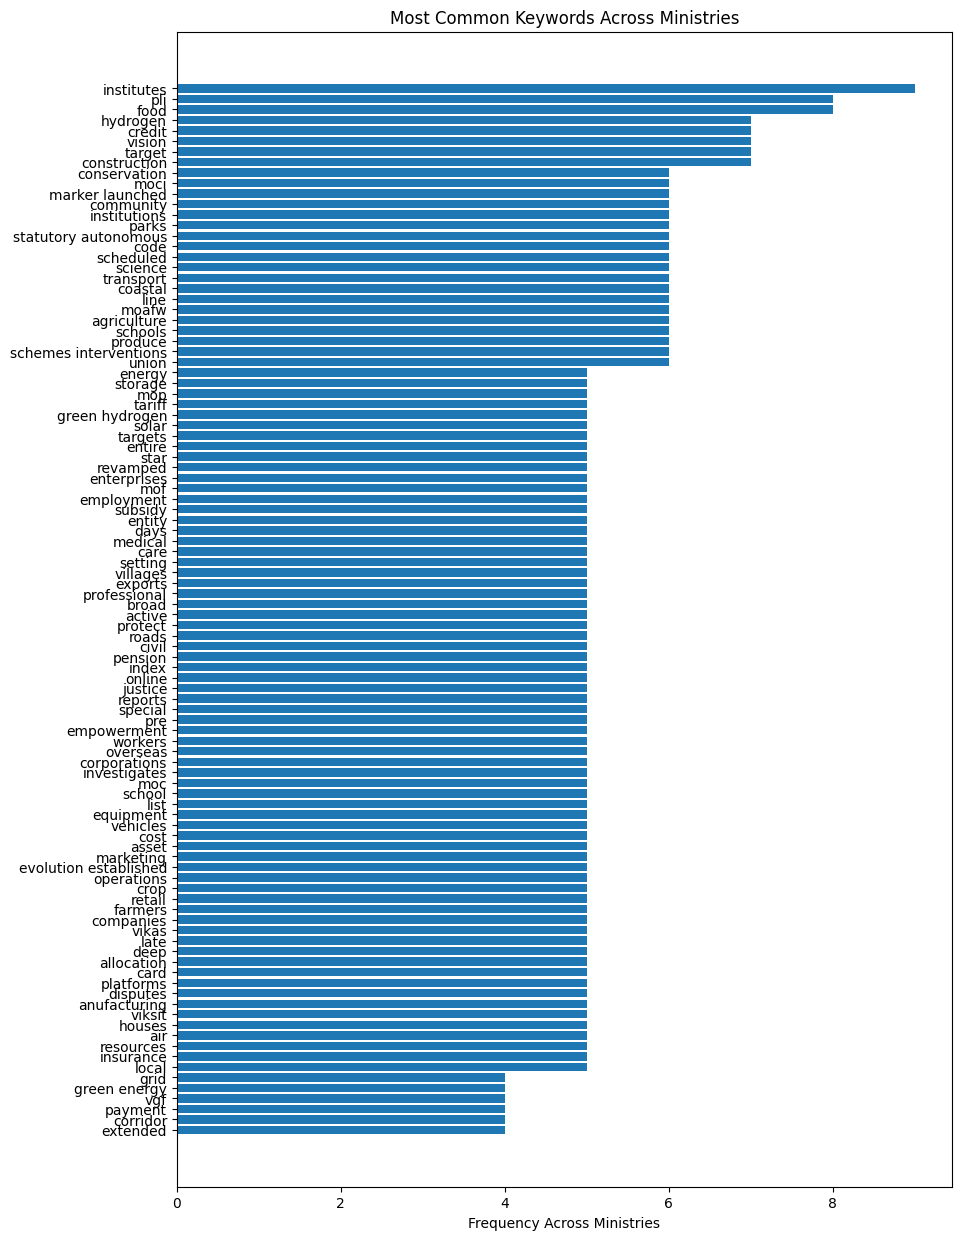

In [19]:
plt.figure(figsize=(10,15))

plt.barh(words, counts)

plt.xlabel("Frequency Across Ministries")
plt.title("Most Common Keywords Across Ministries")

plt.gca().invert_yaxis()

plt.show()

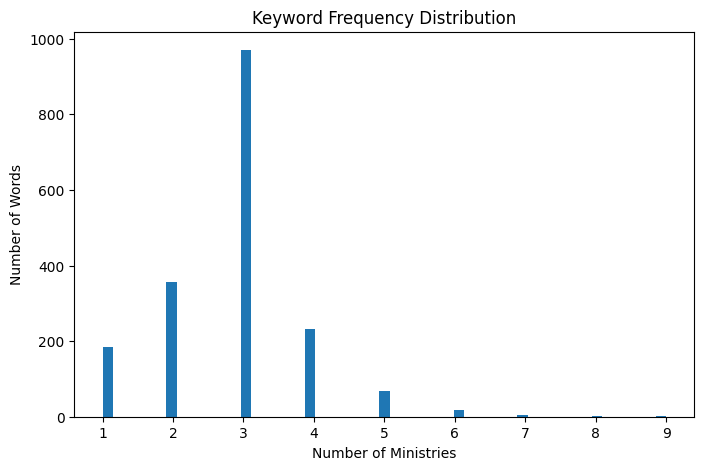

In [20]:
plt.figure(figsize=(8,5))

plt.hist(counter.values(), bins=len(ministry_keywords))

plt.xlabel("Number of Ministries")
plt.ylabel("Number of Words")

plt.title("Keyword Frequency Distribution")

plt.show()

# words appearing in 1 ministry  -> good (specific)
# words appearing in many ministries -> generic